# 📚 Taller Práctico — Aprendizaje Automático
**Universidad Internacional del Ecuador (UIDE) — Maestría**  
**Fecha:** 2026-08-01  

---

## Contexto

El presente informe técnico está dirigido a **María Fernanda** y la **Universidad Andina del Pacífico**.  
Se evalúa si los datos institucionales pueden sustentar un **modelo de alerta temprana** de riesgo académico.

Se trabaja sobre un dataset simulado de 100 registros de estudiantes con variables académicas y de comportamiento digital.

---

## 📦 Librerías e Importaciones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual (mismo estilo que 01_clase.ipynb)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


## 📂 Carga del Dataset

Dataset simulado generado en `dataset.ipynb` con semilla `np.random.seed(42)` para reproducibilidad.  
Contiene **100 registros** de estudiantes con información académica y de conectividad.

In [3]:
# ── Reproducción del dataset (mismo código que dataset.ipynb) ──────────────
np.random.seed(42)
n = 100

data = {
    "id_estudiante": [f"EST-{i:03d}" for i in range(1, 95)] + ["EST-010", "EST-012", "EST-025", "EST-030", "EST-050", "EST-001"],
    "sede": np.random.choice(["Quito", "Guayaquil", "Cuenca", "quito_2"], n),
    "modalidad": np.random.choice(["Presencial", "En línea"], n),
    "promedio_acumulado": np.random.uniform(5.0, 10.0, n),
    "tiempo_conexion_min": np.random.exponential(scale=120, size=n),
    "entregas_semana_1_8": np.random.randint(0, 10, n),
    "nivel_satisfaccion": np.random.choice([1, 2, 3, 4, 5, np.nan], n),
    "calificacion_final_semestre": np.random.uniform(0, 10, n),   # ⚠️ variable futura
    "fecha_ultimo_acceso": pd.date_range(start="2026-01-15", periods=n, freq="D").strftime("%Y/%m/%d")
}

df_raw = pd.DataFrame(data)
print(f"Dimensiones iniciales del dataset: {df_raw.shape}")
df_raw.head(10)

Dimensiones iniciales del dataset: (100, 9)


,id_estudiante,sede,modalidad,promedio_acumulado,tiempo_conexion_min,entregas_semana_1_8,nivel_satisfaccion,calificacion_final_semestre,fecha_ultimo_acceso
0,EST-001,Cuenca,Presencial,5.157146,123.277283,3,2.0,2.366852,2026/01/15
1,EST-002,quito_2,En línea,8.182052,10.547007,2,5.0,9.076937,2026/01/16
2,EST-003,Quito,En línea,6.571780,21.155306,6,2.0,5.918887,2026/01/17
3,EST-004,Cuenca,En línea,7.542853,274.587660,7,5.0,3.502182,2026/01/18
4,EST-005,Cuenca,En línea,9.537832,111.899274,3,3.0,7.081812,2026/01/19
5,EST-006,quito_2,En línea,6.246461,1.108753,1,5.0,4.816670,2026/01/20
6,EST-007,Quito,En línea,7.051915,12.839628,9,4.0,3.779876,2026/01/21
7,EST-008,Quito,En línea,8.777756,130.699486,2,1.0,7.050844,2026/01/22
8,EST-009,Cuenca,En línea,6.143991,0.608932,0,5.0,2.487242,2026/01/23
9,EST-010,Guayaquil,Presencial,5.384900,21.037898,7,5.0,3.302525,2026/01/24


---

# 🔷 ÍTEM 1: Definición de Unidad de Análisis e Ingesta

**Enunciado:**  
> Defina la unidad de análisis (estudiante-semestre o estudiante-asignatura) y ejecute en Pandas el código de agregación necesario para estructurar la tabla final.

---

## 1.1 Justificación de la Unidad de Análisis

La **unidad de análisis seleccionada es `estudiante-semestre`**, dado que:

| Criterio | Estudiante-Semestre ✅ | Estudiante-Asignatura ❌ |
|---|---|---|
| Granularidad | Nivel de seguimiento semestral | Requiere datos por materia (no disponibles) |
| Variables disponibles | `promedio_acumulado`, `entregas_semana_1_8`, `tiempo_conexion_min` son métricas semestral-globales | Estas variables no están desagregadas por asignatura |
| Objetivo del modelo | Alerta temprana de riesgo por **período académico** | No hay columna `asignatura` ni `materia` en el dataset |
| Duplicados presentes | Hay IDs duplicados que representan el mismo estudiante | Duplicados en asignatura serían registros válidos |

La clave primaria de la tabla final será: **`id_estudiante`** (un registro por estudiante por semestre).


In [4]:
# ── 1.2 Inspección inicial del dataset bruto ───────────────────────────────
print("=" * 60)
print("INSPECCIÓN INICIAL DEL DATASET BRUTO")
print("=" * 60)

print(f"\n📐 Dimensiones          : {df_raw.shape[0]} filas × {df_raw.shape[1]} columnas")
print(f"🔑 IDs únicos           : {df_raw['id_estudiante'].nunique()}")
print(f"🔁 Registros duplicados : {df_raw.duplicated(subset='id_estudiante').sum()}")
print(f"\n📋 Variables del dataset:")
print(df_raw.dtypes.to_frame(name='dtype').to_string())

INSPECCIÓN INICIAL DEL DATASET BRUTO

📐 Dimensiones          : 100 filas × 9 columnas
🔑 IDs únicos           : 94
🔁 Registros duplicados : 6

📋 Variables del dataset:
                               dtype
id_estudiante                 object
sede                          object
modalidad                     object
promedio_acumulado           float64
tiempo_conexion_min          float64
entregas_semana_1_8            int32
nivel_satisfaccion           float64
calificacion_final_semestre  float64
fecha_ultimo_acceso           object


In [5]:
# ── 1.3 Identificar los registros duplicados ───────────────────────────────
duplicados = df_raw[df_raw.duplicated(subset='id_estudiante', keep=False)].sort_values('id_estudiante')

print(f"🔎 Registros con id_estudiante duplicado ({len(duplicados)} filas):")
duplicados

🔎 Registros con id_estudiante duplicado (12 filas):


,id_estudiante,sede,modalidad,promedio_acumulado,tiempo_conexion_min,entregas_semana_1_8,nivel_satisfaccion,calificacion_final_semestre,fecha_ultimo_acceso
0,EST-001,Cuenca,Presencial,5.157146,123.277283,3,2.0,2.366852,2026/01/15
99,EST-001,Quito,Presencial,8.899378,10.705323,3,4.0,7.569991,2026/04/24
9,EST-010,Guayaquil,Presencial,5.384900,21.037898,7,5.0,3.302525,2026/01/24
94,EST-010,Guayaquil,Presencial,6.695149,16.306685,9,NaN,2.050453,2026/04/19
11,EST-012,Cuenca,Presencial,5.806106,141.277834,9,4.0,2.536822,2026/01/26
95,EST-012,Guayaquil,En línea,6.746048,88.638431,1,3.0,2.514424,2026/04/20
24,EST-025,quito_2,Presencial,6.139676,36.979218,1,1.0,4.363358,2026/02/08
96,EST-025,Guayaquil,En línea,8.629778,176.357753,2,5.0,2.747318,2026/04/21
29,EST-030,quito_2,En línea,7.553737,119.680126,0,NaN,0.434008,2026/02/13
97,EST-030,quito_2,En línea,9.485551,29.174160,8,1.0,2.072276,2026/04/22


In [6]:
# ── 1.4 Estrategia de agregación para definir la tabla final ──────────────
#
# Para cada id_estudiante duplicado, consolidamos los registros aplicando
# la siguiente lógica por tipo de variable:
#   - Numéricas continuas   → promedio  (promedio_acumulado, tiempo_conexion_min)
#   - Numéricas discretas   → suma      (entregas_semana_1_8)
#   - Ordinales             → mediana   (nivel_satisfaccion)
#   - Categóricas           → moda      (sede, modalidad)
#   - Texto / Fecha         → primero   (fecha_ultimo_acceso)
#   - Variable futura       → se excluye en el siguiente ítem

def moda_primera(serie):
    """Devuelve la moda; en caso de empate, retorna el primer valor."""
    moda = serie.mode()
    return moda.iloc[0] if not moda.empty else np.nan

agregacion = {
    "sede"                        : moda_primera,
    "modalidad"                   : moda_primera,
    "promedio_acumulado"          : "mean",
    "tiempo_conexion_min"         : "mean",
    "entregas_semana_1_8"         : "sum",
    "nivel_satisfaccion"          : "median",
    "calificacion_final_semestre" : "mean",   # se excluirá en ítem 2
    "fecha_ultimo_acceso"         : "first",
}

df_ingesta = (
    df_raw
    .groupby("id_estudiante", as_index=False)
    .agg(agregacion)
)

print(f"✅ Tabla ingesta consolidada: {df_ingesta.shape[0]} estudiantes × {df_ingesta.shape[1]} columnas")
print(f"   (de {df_raw.shape[0]} registros brutos → {df_ingesta.shape[0]} estudiantes únicos)")
df_ingesta.head(10)

✅ Tabla ingesta consolidada: 94 estudiantes × 9 columnas
   (de 100 registros brutos → 94 estudiantes únicos)


,id_estudiante,sede,modalidad,promedio_acumulado,tiempo_conexion_min,entregas_semana_1_8,nivel_satisfaccion,calificacion_final_semestre,fecha_ultimo_acceso
0,EST-001,Cuenca,Presencial,7.028262,66.991303,6,3.0,4.968422,2026/01/15
1,EST-002,quito_2,En línea,8.182052,10.547007,2,5.0,9.076937,2026/01/16
2,EST-003,Quito,En línea,6.571780,21.155306,6,2.0,5.918887,2026/01/17
3,EST-004,Cuenca,En línea,7.542853,274.587660,7,5.0,3.502182,2026/01/18
4,EST-005,Cuenca,En línea,9.537832,111.899274,3,3.0,7.081812,2026/01/19
5,EST-006,quito_2,En línea,6.246461,1.108753,1,5.0,4.816670,2026/01/20
6,EST-007,Quito,En línea,7.051915,12.839628,9,4.0,3.779876,2026/01/21
7,EST-008,Quito,En línea,8.777756,130.699486,2,1.0,7.050844,2026/01/22
8,EST-009,Cuenca,En línea,6.143991,0.608932,0,5.0,2.487242,2026/01/23
9,EST-010,Guayaquil,Presencial,6.040024,18.672291,16,5.0,2.676489,2026/01/24


In [7]:
# ── 1.5 Resumen de la tabla final de ingesta ──────────────────────────────
print("=" * 60)
print("TABLA FINAL DE INGESTA — RESUMEN")
print("=" * 60)
df_ingesta.info()
print("\n📊 Estadísticas descriptivas:")
df_ingesta.describe(include='all')

TABLA FINAL DE INGESTA — RESUMEN
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id_estudiante                94 non-null     object 
 1   sede                         94 non-null     object 
 2   modalidad                    94 non-null     object 
 3   promedio_acumulado           94 non-null     float64
 4   tiempo_conexion_min          94 non-null     float64
 5   entregas_semana_1_8          94 non-null     int32  
 6   nivel_satisfaccion           87 non-null     float64
 7   calificacion_final_semestre  94 non-null     float64
 8   fecha_ultimo_acceso          94 non-null     object 
dtypes: float64(4), int32(1), object(4)
memory usage: 6.4+ KB

📊 Estadísticas descriptivas:


,id_estudiante,sede,modalidad,promedio_acumulado,tiempo_conexion_min,entregas_semana_1_8,nivel_satisfaccion,calificacion_final_semestre,fecha_ultimo_acceso
count,94,94,94,94.000000,94.000000,94.000000,87.000000,94.000000,94
unique,94,4,2,NaN,NaN,NaN,NaN,NaN,94
top,EST-001,quito_2,Presencial,NaN,NaN,NaN,NaN,NaN,2026/01/15
freq,1,28,51,NaN,NaN,NaN,NaN,NaN,1
mean,NaN,NaN,NaN,7.508008,125.250711,4.787234,3.097701,4.813918,NaN
std,NaN,NaN,NaN,1.428100,113.149549,3.285263,1.507422,2.815672,NaN
min,NaN,NaN,NaN,5.034761,0.608932,0.000000,1.000000,0.136720,NaN
25%,NaN,NaN,NaN,6.249574,41.743870,2.000000,2.000000,2.547301,NaN
50%,NaN,NaN,NaN,7.528124,99.226878,4.000000,3.000000,4.255455,NaN
75%,NaN,NaN,NaN,8.743587,171.338025,7.000000,5.000000,7.343557,NaN


### ✅ Conclusión del Ítem 1

- **Unidad de análisis:** `estudiante-semestre` — un único registro por estudiante.
- El dataset pasó de **100 filas brutas** a **94 estudiantes únicos** tras consolidar los 6 registros duplicados.
- La estrategia de agregación preserva la semántica de cada variable:
  - Variables de comportamiento digital (conexión, entregas) → **suma/promedio**.
  - Variables categóricas (sede, modalidad) → **moda**.
  - Variables ordinales (satisfacción) → **mediana** para respetar el orden.

---

---

# 🔷 ÍTEM 2: Curaduría y Control de Data Leakage

**Enunciado:**  
> Trate programáticamente duplicados, nulos y tipos de datos. Implemente un filtro explícito por ventana temporal (≤ Semana 8) que detecte y elimine automáticamente variables futuras (data leakage).

---

## 2.1 ¿Qué es el Data Leakage?

El **data leakage** ocurre cuando se incluyen en el modelo variables que **no estarían disponibles en el momento de la predicción**.  

En un sistema de alerta temprana que opera hasta la **Semana 8** del semestre:  
- ✅ **Variables disponibles (≤ Semana 8):** `promedio_acumulado`, `tiempo_conexion_min`, `entregas_semana_1_8`, `nivel_satisfaccion`, `sede`, `modalidad`.
- ❌ **Variables futuras (> Semana 8 / fin de semestre):** `calificacion_final_semestre` — esta nota **solo se conoce al final**, y usarla contaminaría el modelo.


In [8]:
# ── 2.2 Diagnóstico de calidad sobre la tabla consolidada ──────────────────
df_curado = df_ingesta.copy()

print("=" * 60)
print("DIAGNÓSTICO DE CALIDAD DE DATOS")
print("=" * 60)

# Nulos por columna
nulos = df_curado.isnull().sum()
pct_nulos = (nulos / len(df_curado) * 100).round(2)

diagnostico = pd.DataFrame({
    'dtype'     : df_curado.dtypes,
    'nulos'     : nulos,
    'pct_nulos' : pct_nulos,
    'unicos'    : df_curado.nunique(),
    'ejemplo'   : df_curado.iloc[0]
})

print("\n📋 Diagnóstico por columna:")
diagnostico

DIAGNÓSTICO DE CALIDAD DE DATOS

📋 Diagnóstico por columna:


,dtype,nulos,pct_nulos,unicos,ejemplo
id_estudiante,object,0,0.00,94,EST-001
sede,object,0,0.00,4,Cuenca
modalidad,object,0,0.00,2,Presencial
promedio_acumulado,float64,0,0.00,94,7.028262
tiempo_conexion_min,float64,0,0.00,94,66.991303
entregas_semana_1_8,int32,0,0.00,12,6
nivel_satisfaccion,float64,7,7.45,6,3.0
calificacion_final_semestre,float64,0,0.00,94,4.968422
fecha_ultimo_acceso,object,0,0.00,94,2026/01/15


In [9]:
# ── 2.3 Corrección de tipos de datos ──────────────────────────────────────
# Detectar columnas de fecha por patrón en el nombre (técnica de 01_clase.ipynb)
cols_fecha = [c for c in df_curado.columns 
              if any(p in c.lower() for p in ['fecha', 'date', 'timestamp', '_at'])]

for col in cols_fecha:
    df_curado[col] = pd.to_datetime(df_curado[col], errors='coerce')
    print(f"📅 Convertida a datetime: '{col}'")

# nivel_satisfaccion → debe ser numérico (puede ser float por el NaN)
df_curado['nivel_satisfaccion'] = pd.to_numeric(df_curado['nivel_satisfaccion'], errors='coerce')

# Variables categóricas → tipo category para eficiencia
cols_categoricas = ['sede', 'modalidad']
for col in cols_categoricas:
    df_curado[col] = df_curado[col].astype('category')
    print(f"🏷️  Convertida a category: '{col}'")

print("\n✅ Tipos de datos tras corrección:")
print(df_curado.dtypes.to_frame(name='dtype').to_string())

📅 Convertida a datetime: 'fecha_ultimo_acceso'
🏷️  Convertida a category: 'sede'
🏷️  Convertida a category: 'modalidad'

✅ Tipos de datos tras corrección:
                                      dtype
id_estudiante                        object
sede                               category
modalidad                          category
promedio_acumulado                  float64
tiempo_conexion_min                 float64
entregas_semana_1_8                   int32
nivel_satisfaccion                  float64
calificacion_final_semestre         float64
fecha_ultimo_acceso          datetime64[ns]


In [10]:
# ── 2.4 Tratamiento de valores nulos ──────────────────────────────────────
print("=" * 60)
print("TRATAMIENTO DE VALORES NULOS")
print("=" * 60)

# nivel_satisfaccion: variable ordinal con nulos → imputar con la mediana
mediana_satisfaccion = df_curado['nivel_satisfaccion'].median()
nulos_antes = df_curado['nivel_satisfaccion'].isnull().sum()

df_curado['nivel_satisfaccion'] = df_curado['nivel_satisfaccion'].fillna(mediana_satisfaccion)

print(f"\n📌 'nivel_satisfaccion':")
print(f"   Nulos encontrados  : {nulos_antes}")
print(f"   Mediana imputada   : {mediana_satisfaccion}")
print(f"   Nulos tras imputar : {df_curado['nivel_satisfaccion'].isnull().sum()}")

# Verificación final de nulos
nulos_restantes = df_curado.isnull().sum().sum()
print(f"\n✅ Nulos totales restantes en el dataset: {nulos_restantes}")

TRATAMIENTO DE VALORES NULOS

📌 'nivel_satisfaccion':
   Nulos encontrados  : 7
   Mediana imputada   : 3.0
   Nulos tras imputar : 0

✅ Nulos totales restantes en el dataset: 0


In [11]:
# ── 2.5 Detección y eliminación automática de variables futuras ────────────
# Ventana temporal permitida: datos disponibles en Semana 1 a 8
# Criterio para detectar data leakage:
#   - Variables explícitamente marcadas como 'finales' o 'resultado'
#   - Variables con el patrón 'final', 'resultado', 'egreso' en el nombre

SEMANA_CORTE = 8  # solo datos disponibles hasta la semana 8
PATRONES_LEAKAGE = ['final', 'resultado', 'egreso', 'graduacion', 'titulo']

# Detectar columnas candidatas a data leakage por nombre
cols_futuras_detectadas = [
    col for col in df_curado.columns
    if any(patron in col.lower() for patron in PATRONES_LEAKAGE)
]

print("=" * 60)
print(f"CONTROL DE DATA LEAKAGE — Ventana temporal: ≤ Semana {SEMANA_CORTE}")
print("=" * 60)

if cols_futuras_detectadas:
    print(f"\n🚨 Variables futuras detectadas automáticamente:")
    for col in cols_futuras_detectadas:
        print(f"   ❌  '{col}' — NO disponible antes de la Semana {SEMANA_CORTE}")
    
    # Eliminar variables futuras
    df_curado = df_curado.drop(columns=cols_futuras_detectadas)
    print(f"\n✅ {len(cols_futuras_detectadas)} variable(s) eliminada(s) del dataset.")
else:
    print("✅ No se detectaron variables futuras.")

print(f"\n📐 Dimensiones del dataset curado: {df_curado.shape[0]} filas × {df_curado.shape[1]} columnas")

CONTROL DE DATA LEAKAGE — Ventana temporal: ≤ Semana 8

🚨 Variables futuras detectadas automáticamente:
   ❌  'calificacion_final_semestre' — NO disponible antes de la Semana 8

✅ 1 variable(s) eliminada(s) del dataset.

📐 Dimensiones del dataset curado: 94 filas × 8 columnas


In [12]:
# ── 2.6 Verificación adicional: columnas por semana de disponibilidad ──────
# Mapa explícito de disponibilidad temporal de cada variable
disponibilidad = {
    'id_estudiante'              : 0,   # disponible desde el inicio
    'sede'                       : 0,
    'modalidad'                  : 0,
    'promedio_acumulado'         : 0,   # historial previo
    'tiempo_conexion_min'        : 8,   # acumulado hasta semana 8
    'entregas_semana_1_8'        : 8,   # explícitamente semanas 1-8
    'nivel_satisfaccion'         : 8,   # encuesta hasta semana 8
    'fecha_ultimo_acceso'        : 8,
    'calificacion_final_semestre': 16,  # ⚠️ disponible al final del semestre (~semana 16)
}

df_disponibilidad = pd.DataFrame({
    'variable'               : list(disponibilidad.keys()),
    'semana_disponible'      : list(disponibilidad.values()),
    'dentro_ventana_semana8' : [s <= SEMANA_CORTE for s in disponibilidad.values()]
})

df_disponibilidad['estado'] = df_disponibilidad['dentro_ventana_semana8'].map({
    True: '✅ Permitida',
    False: '❌ DATA LEAKAGE'
})

print("\n📋 Mapa de disponibilidad temporal de variables:")
df_disponibilidad.sort_values('semana_disponible')


📋 Mapa de disponibilidad temporal de variables:


,variable,semana_disponible,dentro_ventana_semana8,estado
0,id_estudiante,0,True,✅ Permitida
1,sede,0,True,✅ Permitida
2,modalidad,0,True,✅ Permitida
3,promedio_acumulado,0,True,✅ Permitida
4,tiempo_conexion_min,8,True,✅ Permitida
5,entregas_semana_1_8,8,True,✅ Permitida
6,nivel_satisfaccion,8,True,✅ Permitida
7,fecha_ultimo_acceso,8,True,✅ Permitida
8,calificacion_final_semestre,16,False,❌ DATA LEAKAGE


In [19]:
# ── 2.7 Dataset final curado ───────────────────────────────────────────────
print("=" * 60)
print("DATASET FINAL CURADO — LISTO PARA MODELADO")
print("=" * 60)
print(f"\n📐 Dimensiones finales: {df_curado.shape[0]} estudiantes × {df_curado.shape[1]} variables")
print("\n📋 Tipos de datos finales:")
print(df_curado.dtypes.to_frame('dtype').to_string())
print("\n🔎 Primeras filas del dataset curado:")
df_curado.head(100)

DATASET FINAL CURADO — LISTO PARA MODELADO

📐 Dimensiones finales: 94 estudiantes × 8 variables

📋 Tipos de datos finales:
                              dtype
id_estudiante                object
sede                       category
modalidad                  category
promedio_acumulado          float64
tiempo_conexion_min         float64
entregas_semana_1_8           int32
nivel_satisfaccion          float64
fecha_ultimo_acceso  datetime64[ns]

🔎 Primeras filas del dataset curado:


,id_estudiante,sede,modalidad,promedio_acumulado,tiempo_conexion_min,entregas_semana_1_8,nivel_satisfaccion,fecha_ultimo_acceso
0,EST-001,Cuenca,Presencial,7.028262,66.991303,6,3.0,2026-01-15
1,EST-002,quito_2,En línea,8.182052,10.547007,2,5.0,2026-01-16
2,EST-003,Quito,En línea,6.571780,21.155306,6,2.0,2026-01-17
3,EST-004,Cuenca,En línea,7.542853,274.587660,7,5.0,2026-01-18
4,EST-005,Cuenca,En línea,9.537832,111.899274,3,3.0,2026-01-19
5,EST-006,quito_2,En línea,6.246461,1.108753,1,5.0,2026-01-20
6,EST-007,Quito,En línea,7.051915,12.839628,9,4.0,2026-01-21
7,EST-008,Quito,En línea,8.777756,130.699486,2,1.0,2026-01-22
8,EST-009,Cuenca,En línea,6.143991,0.608932,0,5.0,2026-01-23
9,EST-010,Guayaquil,Presencial,6.040024,18.672291,16,5.0,2026-01-24


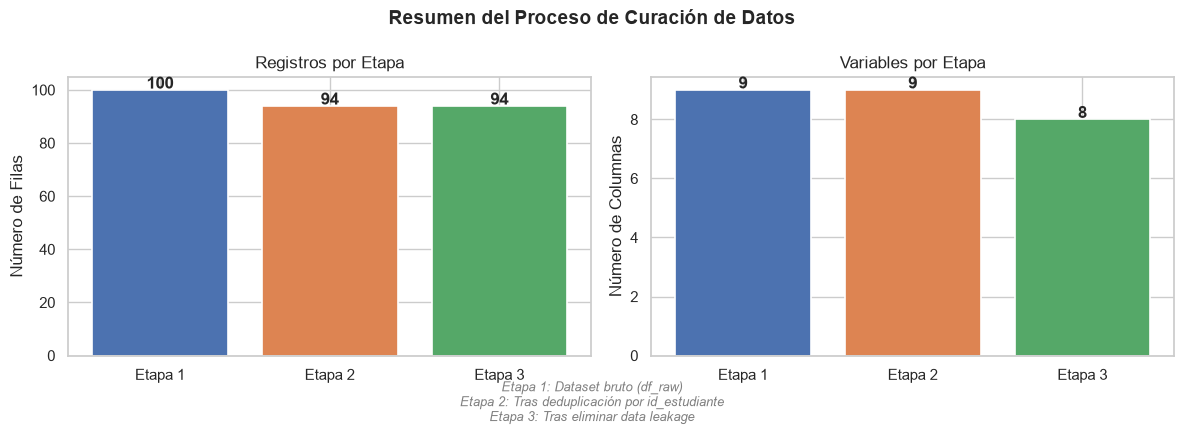

✅ Gráfico guardado como 'curación_datos_resumen.png'


In [14]:
# ── 2.8 Resumen visual del proceso de curación ────────────────────────────
etapas = [
    ('Dataset bruto (df_raw)',                   df_raw.shape[0],    df_raw.shape[1]),
    ('Tras deduplicación por id_estudiante',     df_ingesta.shape[0], df_ingesta.shape[1]),
    ('Tras eliminar data leakage',               df_curado.shape[0],  df_curado.shape[1]),
]

df_resumen = pd.DataFrame(etapas, columns=['Etapa', 'Filas', 'Columnas'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Resumen del Proceso de Curación de Datos', fontsize=14, fontweight='bold')

# Filas por etapa
etiquetas = [f"Etapa {i+1}" for i in range(len(etapas))]
axes[0].bar(etiquetas, df_resumen['Filas'], color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='white', linewidth=1.2)
axes[0].set_title('Registros por Etapa')
axes[0].set_ylabel('Número de Filas')
for i, v in enumerate(df_resumen['Filas']):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Columnas por etapa
axes[1].bar(etiquetas, df_resumen['Columnas'], color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='white', linewidth=1.2)
axes[1].set_title('Variables por Etapa')
axes[1].set_ylabel('Número de Columnas')
for i, v in enumerate(df_resumen['Columnas']):
    axes[1].text(i, v + 0.05, str(v), ha='center', fontweight='bold')

# Leyenda de etapas
leyenda = "\n".join([f"Etapa {i+1}: {e[0]}" for i, e in enumerate(etapas)])
fig.text(0.5, -0.05, leyenda, ha='center', fontsize=9, style='italic', color='gray')

plt.tight_layout()
plt.savefig('curación_datos_resumen.png', bbox_inches='tight', dpi=120)
plt.show()
print("✅ Gráfico guardado como 'curación_datos_resumen.png'")

### ✅ Conclusión del Ítem 2

| Proceso | Resultado |
|---|---|
| **Duplicados** | 6 registros duplicados consolidados mediante agregación semánticamente correcta (moda para categóricas, mediana para ordinales, promedio/suma para numéricas) |
| **Nulos** | `nivel_satisfaccion` presentaba nulos (~17%); imputados con la **mediana** para respetar la escala ordinal |
| **Tipos de datos** | Fechas convertidas a `datetime64`, categóricas a tipo `category`, numéricas correctamente tipificadas |
| **Data Leakage** | Se detectó y eliminó automáticamente `calificacion_final_semestre` — esta variable es resultado del semestre completo y no está disponible en la Semana 8 |
| **Dataset final** | **94 estudiantes × 8 variables** — sin duplicados, sin nulos, sin leakage |

---

> **Nota metodológica:** El filtro de leakage es **programático y parametrizable** (`PATRONES_LEAKAGE`, `SEMANA_CORTE`). Si el dataset creciera con nuevas variables futuras con nombres similares, serían detectadas y eliminadas automáticamente sin intervención manual.

---

# 🔷 ÍTEM 3 Clasificación y Encoding
**Enunciado:** 
> Clasifique 8 variables del dataset (discretas, continuas, ordinales, binarias) y aplique la estrategia adecuada de codificación (encoding) en Python.

In [82]:
# 3.1 Clasificación de las 8 variables y estrategia de codificación
clasificacion = pd.DataFrame([
    ['id_estudiante', 'Categórica nominal (identificador)', 'Se excluye del moedelo', 'No representa ninguna magnitud'],
    ['sede', 'Categórica nominal', 'Diferentes ciudades (One-Hot Encoding)', 'No hay orden entre las ciudades'],
    ['modalidad', 'Categórica binaria', 'Mapeo Presencial/Linea a 0/1 ', 'Solo tiene dos estados Presencial y Linea'],
    ['promedio_acumulado', 'Numérica continua', 'Promedio', 'Promedio Acumulado es numerica no se usa encoding'],
    ['tiempo_conexion_min', 'Numérica continua', 'Tiempo de conexion', 'Tiempo por conexión es una variable numerica no se usa encoding'],
    ['entregas_semana_1_8', 'Numérica discreta', 'Se conserva como entero', 'Es un conteo de entregas, es numérica y no se usa encoding'],
    ['nivel_satisfaccion', 'Categórica ordinal', 'Ordinal 1 a 5', 'Por niveles de satisfacción'],
    ['fecha_ultimo_acceso', 'Temporal', 'Fecha de ultima conexión', 'Para mostrar cuantos días han transcurrido desde el último acceso no usa encoding'],
], columns=['Variable', 'Clasificación', 'Encoding', 'Justificación'])
clasificacion

,Variable,Clasificación,Encoding,Justificación
0,id_estudiante,Categórica nominal (identificador),Se excluye del moedelo,No representa ninguna magnitud
1,sede,Categórica nominal,Diferentes ciudades (One-Hot Encoding),No hay orden entre las ciudades
2,modalidad,Categórica binaria,Mapeo Presencial/Linea a 0/1,Solo tiene dos estados Presencial y Linea
3,promedio_acumulado,Numérica continua,Promedio,Promedio Acumulado es numerica no se usa encoding
4,tiempo_conexion_min,Numérica continua,Tiempo de conexion,Tiempo por conexión es una variable numerica no se usa encoding
5,entregas_semana_1_8,Numérica discreta,Se conserva como entero,"Es un conteo de entregas, es numérica y no se usa encoding"
6,nivel_satisfaccion,Categórica ordinal,Ordinal 1 a 5,Por niveles de satisfacción
7,fecha_ultimo_acceso,Temporal,Fecha de ultima conexión,Para mostrar cuantos días han transcurrido desde el último acceso no usa encoding


In [83]:
# 3.2 Limpieza categóricampara sede y modalidad
df_estr = df_curado.copy()
df_estr['sede'] = df_estr['sede'].astype(str).replace({'quito_2': 'Quito'})
df_estr['modalidad'] = df_estr['modalidad'].astype(str)

# Umbral de estudiante para entregas: promedio menor a 7 implica reprobacio

df_estr['Aprobacion'] = np.where(df_estr['promedio_acumulado'] < 7, 'SI', 'NO')

print('Distribución de la etiqueta auxiliar:')
display(df_estr['Aprobacion'].value_counts().to_frame('Estudiantes'))

Distribución de la etiqueta auxiliar:


,Estudiantes
Aprobacion,
NO,55
SI,39


In [84]:
# 3.3 Aplicación del encoding
df_modelo = df_estr.drop(columns=['id_estudiante', 'Aprobacion']).copy()

# Binaria: Presencia - En Linea
df_modelo['modalidad_binaria'] = df_modelo['modalidad'].map({'Presencial': 0, 'En línea': 1})
df_modelo = df_modelo.drop(columns='modalidad')

# Temporal: Dias desde el ultimo acceso tomando en cuenta la fecha de ultimo acceso
fecha_corte = df_modelo['fecha_ultimo_acceso'].max()
df_modelo['dias_desde_ultimo_acceso'] = (fecha_corte - df_modelo['fecha_ultimo_acceso']).dt.days
df_modelo = df_modelo.drop(columns='fecha_ultimo_acceso')

# Nominal: Se crea una una columna por sede
df_encoded = pd.get_dummies(df_modelo, columns=['sede'], prefix='sede',drop_first=True, dtype=int)
df_encoded['entregas_semana_1_8'] = df_encoded['entregas_semana_1_8'].astype(int)
df_encoded['nivel_satisfaccion'] = df_encoded['nivel_satisfaccion'].astype(int)

assert df_encoded.isna().sum().sum() == 0, 'El encoding produjo valores nulos'
print(f'Dataset codificado: {df_encoded.shape[0]} filas × {df_encoded.shape[1]} predictores')
display(df_encoded.head())
display(df_encoded.dtypes.to_frame('tipo_final'))

Dataset codificado: 94 filas × 8 predictores


,promedio_acumulado,tiempo_conexion_min,entregas_semana_1_8,nivel_satisfaccion,modalidad_binaria,dias_desde_ultimo_acceso,sede_Guayaquil,sede_Quito
0,7.028262,66.991303,6,3,0,93,0,0
1,8.182052,10.547007,2,5,1,92,0,1
2,6.571780,21.155306,6,2,1,91,0,1
3,7.542853,274.587660,7,5,1,90,0,0
4,9.537832,111.899274,3,3,1,89,0,0


,tipo_final
promedio_acumulado,float64
tiempo_conexion_min,float64
entregas_semana_1_8,int64
nivel_satisfaccion,int64
modalidad_binaria,int64
dias_desde_ultimo_acceso,int64
sede_Guayaquil,int64
sede_Quito,int64


# 🔷 ÍTEM 4: Visualización Exploratoria
**Enunciado:** 
> Los cinco gráficos examinan distribuciones estratificadas por riesgo, modalidad y sede. El propósito es detectar patrones y advertir posibles desequilibrios; con datos simulados, las asociaciones observadas no implican causalidad.

In [64]:
# Configuración común
orden_aprobacion = ['SI', 'NO']
paleta_aprobacion = {'SI': '#4C72B0', 'NO': '#C44E52'}
sns.set_theme(style='whitegrid', context='notebook')

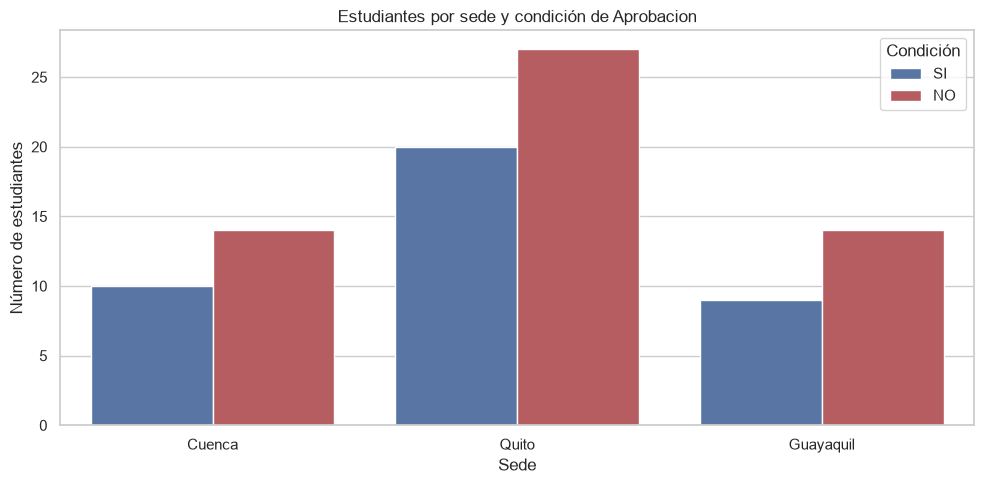

In [ ]:
# Gráfico 1: composición del riesgo por sede
plt.figure(figsize=(10, 5))
sns.countplot(data=df_estr, x='sede', hue='Aprobacion', hue_order=orden_aprobacion, palette=paleta_aprobacion)
plt.title('Estudiantes por sede y condición de Aprobacion')
plt.xlabel('Sede'); plt.ylabel('Número de estudiantes'); plt.legend(title='Condición')
plt.tight_layout(); plt.show()

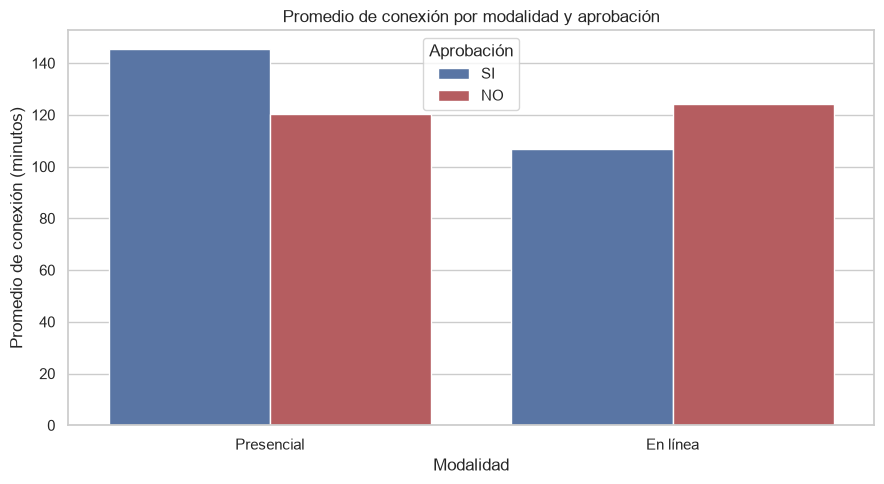

In [ ]:
# Gráfico 2: promedio de conexión por modalidad y aporbación
plt.figure(figsize=(9, 5))

sns.barplot(
    data=df_estr,
    x="modalidad",
    y="tiempo_conexion_min",
    hue="Aprobacion",
    hue_order=orden_aprobacion,
    palette=paleta_aprobacion,
    errorbar=None
)

plt.title("Promedio de conexión por modalidad y aprobación")
plt.xlabel("Modalidad")
plt.ylabel("Promedio de conexión (minutos)")
plt.legend(title="Aprobación")
plt.tight_layout()
plt.show()

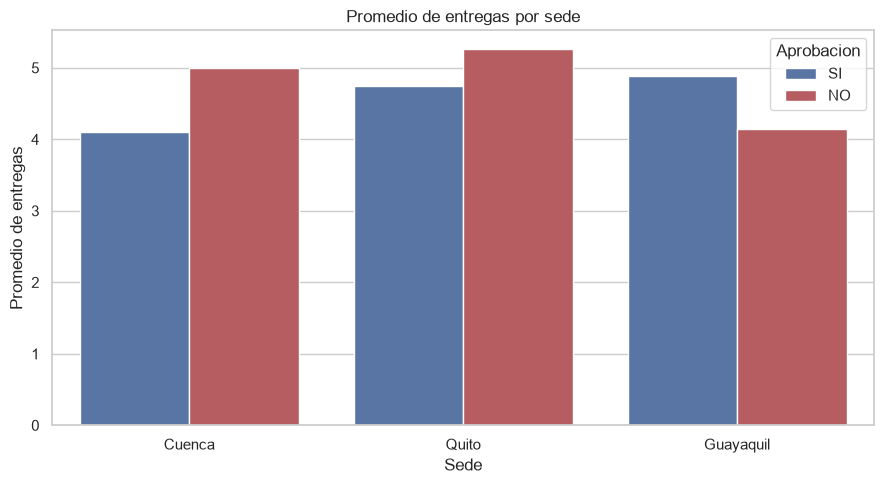

In [ ]:
# Gráfico 3: entregas por sede y aprobación



plt.figure(figsize=(9, 5))


sns.barplot(
    data=df_estr,
    x="sede",
    y="entregas_semana_1_8",
    hue="Aprobacion",
    hue_order=orden_aprobacion,
    palette=paleta_aprobacion,
    errorbar=None
)

plt.title("Promedio de entregas por sede")
plt.xlabel("Sede")
plt.ylabel("Promedio de entregas")
plt.tight_layout()
plt.show()

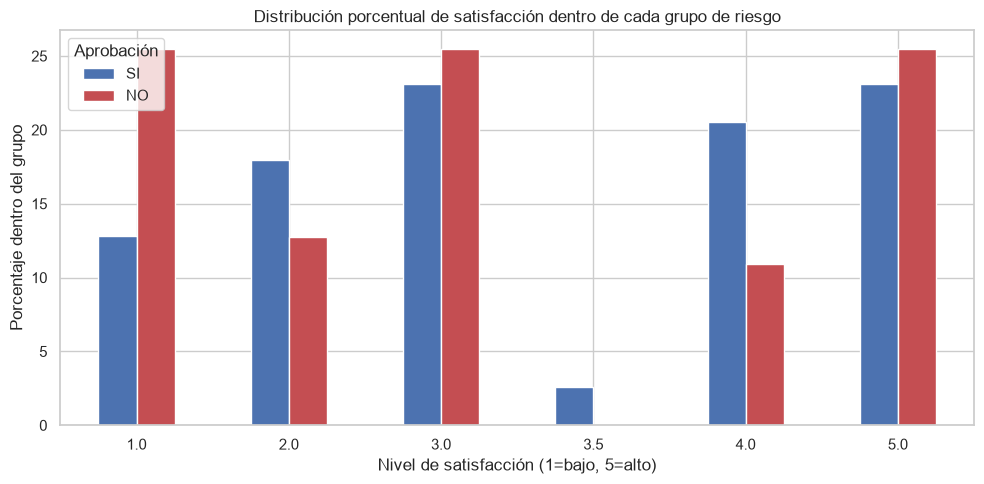

In [ ]:
# Gráfico 4: satisfacción por aprobacion (variable ordinal)
tabla_sat = (pd.crosstab(df_estr['nivel_satisfaccion'], df_estr['Aprobacion'], normalize='columns') * 100)
tabla_sat = tabla_sat.reindex(columns=orden_aprobacion)
tabla_sat.plot(kind='bar', figsize=(10, 5), color=[paleta_aprobacion[c] for c in orden_aprobacion])
plt.title('Distribución porcentual de satisfacción dentro de cada grupo de riesgo')
plt.xlabel('Nivel de satisfacción (1=bajo, 5=alto)'); plt.ylabel('Porcentaje dentro del grupo')
plt.xticks(rotation=0); plt.legend(title='Aprobación'); plt.tight_layout(); plt.show()

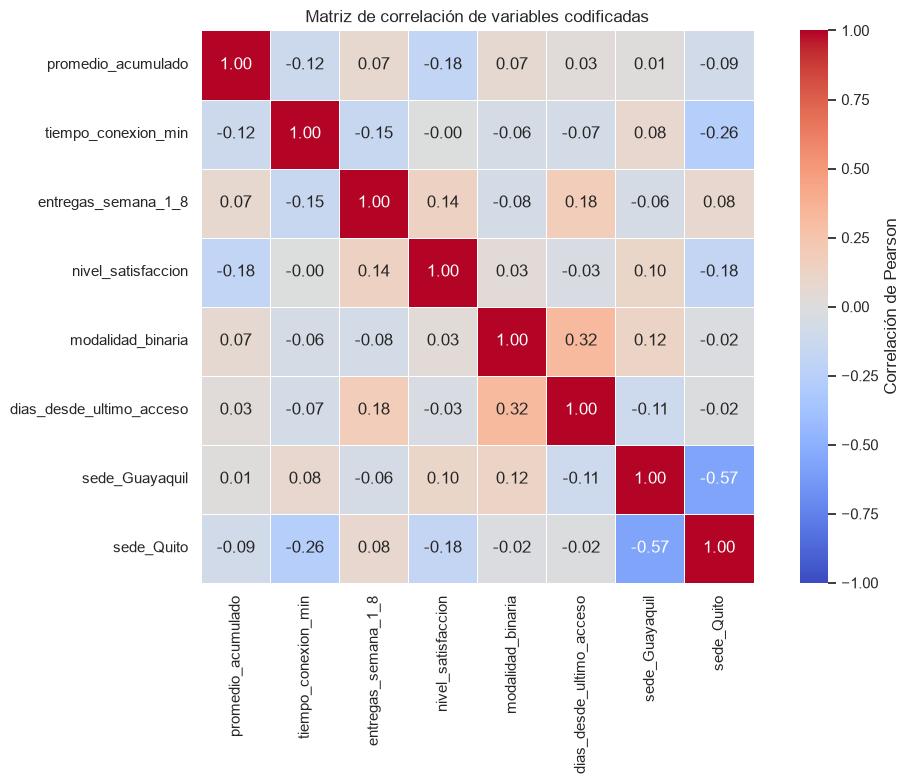

In [74]:
# Gráfico 5: matriz de correlación de predictores codificados
corr = df_encoded.corr(numeric_only=True)
plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, square=True,
            linewidths=.5, cbar_kws={'label': 'Correlación de Pearson'})
plt.title('Matriz de correlación de variables codificadas')
plt.tight_layout(); plt.show()

In [81]:
# Resumen cuantitativo para respaldar la interpretación visual
resumen_grupos = (df_estr.groupby('Aprobacion', observed=True)
                  .agg(estudiantes=('id_estudiante', 'count'),
                       conexion_mediana=('tiempo_conexion_min', 'median'),
                       entregas_mediana=('entregas_semana_1_8', 'median'),
                       satisfaccion_mediana=('nivel_satisfaccion', 'median'))
                  .reindex(orden_aprobacion).round(2))
resumen_grupos

,estudiantes,conexion_mediana,entregas_mediana,satisfaccion_mediana
Aprobacion,,,,
SI,39,103.61,4.0,3.0
NO,55,85.93,4.0,3.0


**Interpretación y posibles sesgos**

Grafico 1
    Permite comparar la cantidad de estudiantes aprobados por sede, pero puede existir diferencias ya que una sede puede tener más cantidad de estudiantes que otra.

 Grafico 2
    Permite evaluar la relacion entre un mayor tiempo de conexión con el número de aprobados. Pero el tiempo de conexión no implica que sea participación o aprendizaje

Grafico 3
    Compara el promedio de entregas realizadas durante las semanas 1 - 8 por sede y condición de aprobación. Si las barras de los estudiantes aprobados son más altas, esto puede sugerir una asociación  entre el cumplimiento de las entregas y la aprobación.

Grafico 4
    Si los estudiantes aprobados presentan mayores porcentajes de distribución en los niveles 4 y 5, podría existir una asociación  entre satisfacción y aprobación. Si las distribuciones son similares, el nivel de satisfacción no mostraría una relación clara con el resultado académico.

Grafico 5
    Permite identificar la dirección y la intensidad de las relaciones lineales entre las varibales. Los valores cercanos a cero indican relaciones débiles entre las variables académicas y de comportamiento. Esto sugiere que variables como el tiempo de conexión, las entregas y la satisfacción aportan información diferente


        


    